In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("netflix_titles.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
print("Total titles:", len(df))
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())

Total titles: 8807

Column names: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Missing values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


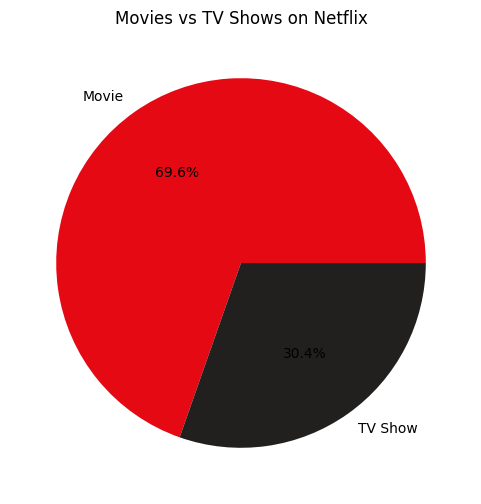

In [5]:
plt.figure(figsize=(6,6))
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#E50914','#221F1F'])
plt.title('Movies vs TV Shows on Netflix')
plt.ylabel('')
plt.show()

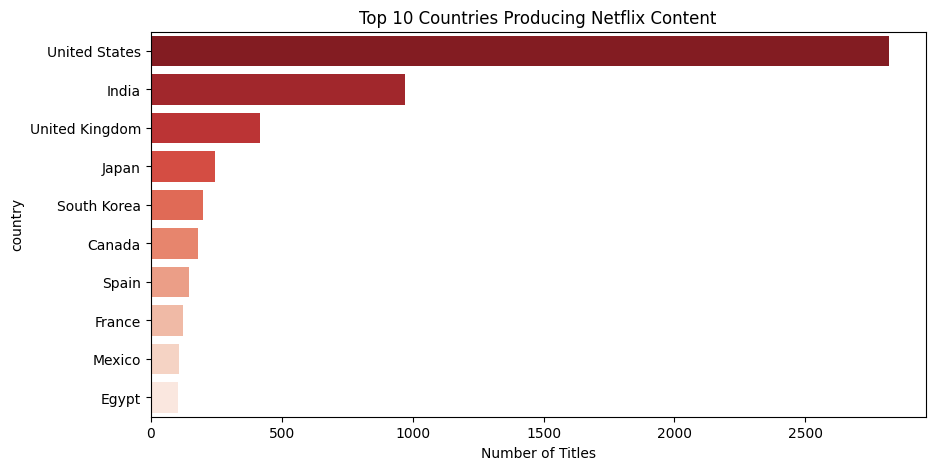

In [6]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Number of Titles')
plt.show()

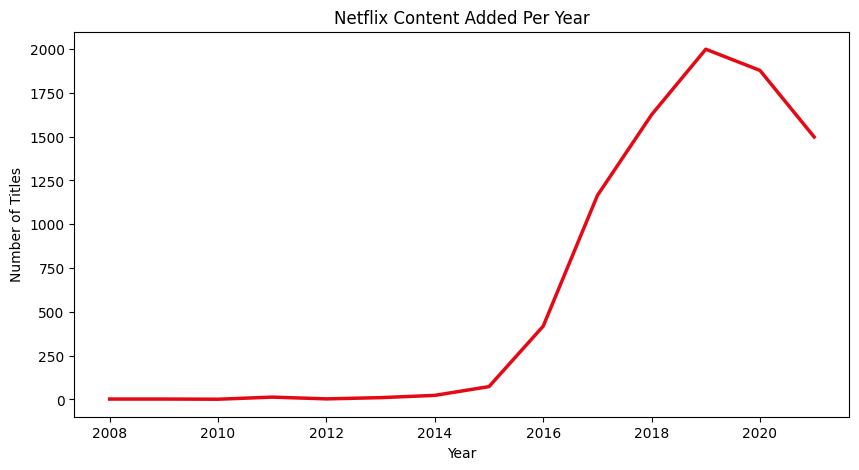

In [7]:
df['year_added'] = pd.to_datetime(df['date_added'], errors='coerce').dt.year
yearly = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly.index, y=yearly.values, color='#E50914', linewidth=2.5)
plt.title('Netflix Content Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

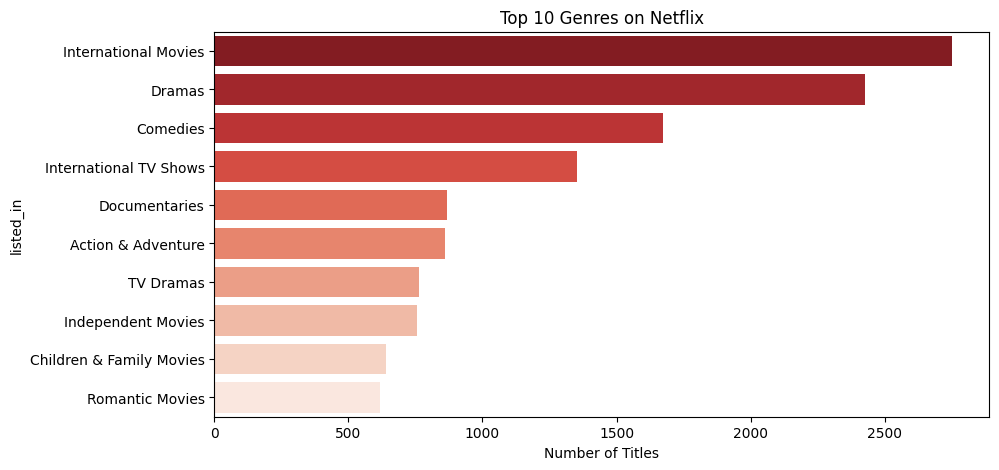

In [8]:
genres = df['listed_in'].str.split(',').explode().str.strip()
top_genres = genres.value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.show()

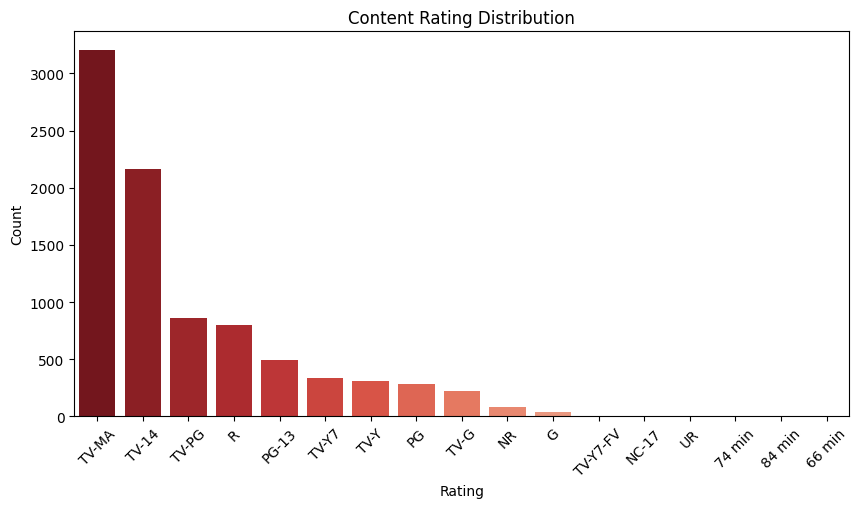

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='Reds_r')
plt.title('Content Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [10]:
# Summary of findings
print("""
NETFLIX DATA ANALYSIS - KEY FINDINGS
=====================================
1. Total titles analysed:", len(df))
2. Movies make up the majority of Netflix content
3. United States is the top content-producing country
4. Netflix content additions peaked around 2019-2020
5. International Movies and Dramas are the most common genres
6. TV-MA is the most common content rating
""")


NETFLIX DATA ANALYSIS - KEY FINDINGS
1. Total titles analysed:", len(df))
2. Movies make up the majority of Netflix content
3. United States is the top content-producing country
4. Netflix content additions peaked around 2019-2020
5. International Movies and Dramas are the most common genres
6. TV-MA is the most common content rating

